In [1]:
from libraries import *

import statsmodels.api as sm
from os.path import exists


In [31]:
trainfile="/home/eraslab1/Projects/E3Ligase/analysisSingle/ComboData/outputs/anndata/adataKOSingles_train.h5ad"

In [32]:
project_dir="/home/eraslab1/Projects/E3Ligase/analysisSingle/ComboData/"

In [33]:
save_dir='/home/eraslab1/Projects/E3Ligase/analysisSingle/ComboData/outputs/Models/'

In [34]:
os.chdir(project_dir)

annDat= sc.read(trainfile)


In [35]:
num_conditions = 14
myConditions = ['Ambra1', 'Ankfy1', 'Crebbp', 'Ep300', 'Fbxw7', 'Klhl6',
                'March6', 'Pparg', 'Rfwd2', 'Socs3', 'Syvn1', 'Traf2', 'Trip12', 'Wdr82']
target_conditions_dict = {}

for i in range(num_conditions):
    for j in range(i, num_conditions):
        condition = torch.zeros(num_conditions)
        condition[i] = 1
        if j == i:
            name = f'perturb_{myConditions[i]}'
            target_conditions_dict[name] = condition
        # else:
        #     name = f'perturb_{myConditions[i]}_{myConditions[j]}'
        #     condition[j] = 1
        # target_conditions_dict[name] = condition

ctrl_condition = torch.zeros(num_conditions)
target_conditions_dict['perturb_ctrl'] = ctrl_condition


In [6]:
target_conditions_dict

{'perturb_Ambra1': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Ankfy1': tensor([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Crebbp': tensor([1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Ep300': tensor([1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Fbxw7': tensor([1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Klhl6': tensor([1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_March6': tensor([1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Pparg': tensor([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Rfwd2': tensor([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'perturb_Ambra1_Socs3': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'perturb_Ambra1_Syvn1': tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 '

In [36]:
model_dir="model_alpha_7_KOSingles_l16"

In [37]:
expressionMatrix = np.load(os.path.join(save_dir, model_dir, 
                                        'generated_samples/perturb_ctrl_best.npy'), allow_pickle=True)



In [41]:
guideMatrix = pd.DataFrame(np.zeros((357 * 15,
                                      len(target_conditions_dict.keys()))))
guideMatrix.columns = target_conditions_dict.keys()
guideMatrix.loc[0:356,"perturb_ctrl"] = 1
i=357

for name, target_condition in target_conditions_dict.items():
    if name != "perturb_ctrl":
        print(name)
        pertCells = np.load(os.path.join(save_dir, model_dir,
                                         "generated_samples", 
                                         name+"_best.npy"), allow_pickle=True)
        expressionMatrix = np.concatenate((expressionMatrix, pertCells))
        guideMatrix.loc[i:(i+356),name] = 1
        i = i+357
        print(expressionMatrix.shape)


perturb_Ambra1
(714, 1404)
perturb_Ankfy1
(1071, 1404)
perturb_Crebbp
(1428, 1404)
perturb_Ep300
(1785, 1404)
perturb_Fbxw7
(2142, 1404)
perturb_Klhl6
(2499, 1404)
perturb_March6
(2856, 1404)
perturb_Pparg
(3213, 1404)
perturb_Rfwd2
(3570, 1404)
perturb_Socs3
(3927, 1404)
perturb_Syvn1
(4284, 1404)
perturb_Traf2
(4641, 1404)
perturb_Trip12
(4998, 1404)
perturb_Wdr82
(5355, 1404)


In [42]:
guideMatrix

,perturb_Ambra1,perturb_Ankfy1,perturb_Crebbp,perturb_Ep300,perturb_Fbxw7,perturb_Klhl6,perturb_March6,perturb_Pparg,perturb_Rfwd2,perturb_Socs3,perturb_Syvn1,perturb_Traf2,perturb_Trip12,perturb_Wdr82,perturb_ctrl
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [45]:
guideMatrix.sum(axis=0)

perturb_Ambra1    357.0
perturb_Ankfy1    357.0
perturb_Crebbp    357.0
perturb_Ep300     357.0
perturb_Fbxw7     357.0
perturb_Klhl6     357.0
perturb_March6    357.0
perturb_Pparg     357.0
perturb_Rfwd2     357.0
perturb_Socs3     357.0
perturb_Syvn1     357.0
perturb_Traf2     357.0
perturb_Trip12    357.0
perturb_Wdr82     357.0
perturb_ctrl      357.0
dtype: float64

In [39]:
annDatControl= sc.read("outputs/anndata/adataControl.h5ad")

In [19]:
annDatControl.X[0,:]

array([-0.83110046,  0.28474647,  0.9754703 , ...,  1.308574  ,
        1.6349021 , -0.8446901 ], dtype=float32)

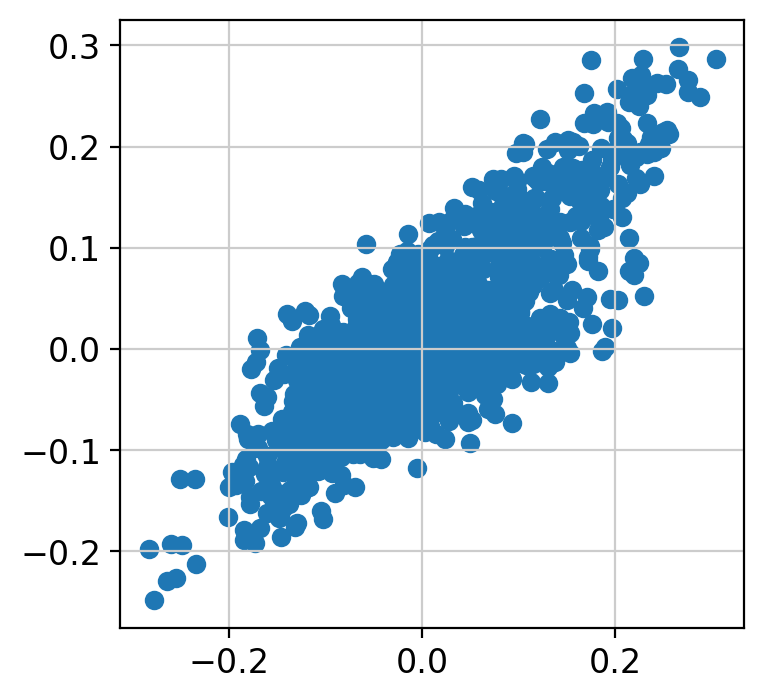

In [40]:
import matplotlib.pyplot as plt
plt.scatter(annDatControl.X.mean(axis=0), expressionMatrix.mean(axis=0))
plt.show()